# Busca S1 de taxa de aprendizado (RQ1/RQ2)

Notebook **somente de leitura** — não treina nada. Lê os caches produzidos por
`scripts/rqs/run_busca_lr.py` e `scripts/rqs/lr_escolhida.py`:

| arquivo | o que é |
|---|---|
| `results/rqs/busca_lr.csv` | uma linha por (encoder, federação, regime, LR, **rodada**) |
| `results/rqs/lr_escolhida.csv` | a LR decidida por (encoder, federação, **regime**) |
| `results/rqs/lr_escolhida_grade4pts.csv` | registro da grade antiga de 4 pontos — só para comparação |

A busca varre `LR_GRID` em **dois regimes de rótulo** por célula (encoder × federação):
`k=1` e `Full`. `k=2` e `k=4` **não** são buscados — herdam a LR do `k=1` (decisão D9,
`docs/desenho_experimental.md`).

**O que este notebook mostra**

1. **Curvas `val_acc` × LR**, uma faceta por (federação × encoder), com os dois regimes sobrepostos — é onde se vê que os regimes discordam.
2. **Mapa das LRs escolhidas**, por regime.
3. **Regret das regras de decisão** — quanto cada regra perde contra o ótimo de cada regime.

> Roda com a busca incompleta: as células sem a grade inteira aparecem vazias em vez de quebrar.

## 1. Setup

In [1]:
import sys
from pathlib import Path

_p = Path.cwd()
PROJECT_ROOT = None
while _p != _p.parent:
    if (_p / "minerva").is_dir() and (_p / "scripts").is_dir():
        PROJECT_ROOT = _p
        break
    _p = _p.parent
if PROJECT_ROOT is None:
    raise RuntimeError(f"Raiz do projeto não encontrada a partir de {Path.cwd()}")

for p in (PROJECT_ROOT, PROJECT_ROOT / "scripts"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

print(f"PROJECT_ROOT = {PROJECT_ROOT}")

PROJECT_ROOT = /home/miguel.barreto/fed-har


In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FuncFormatter

from rqs.config import ENCODERS, FEDERACOES, FULL_SHOTS, LR_GRID

warnings.filterwarnings("ignore")

RESULTS = PROJECT_ROOT / "results" / "rqs"
REGIMES = ["1", str(FULL_SHOTS)]
ROTULO_REGIME = {"1": "k=1 (rótulo escasso)", str(FULL_SHOTS): "Full (rótulo farto)"}

# --- Paleta -------------------------------------------------------------
# Slots 1-2 da paleta de referência do skill `dataviz`. Documentada como
# validada em all-pairs nos dois modos (CVD ΔE 9.2 / normal 24.0 no claro).
# Duas séries só: os dois REGIMES. Encoder e federação viram facetas, não cor --
# 4 encoders em cor reprovariam o piso de contraste em small multiples.
C_K1, C_FULL = "#2a78d6", "#eb6834"      # azul, laranja
COR_REGIME = {"1": C_K1, str(FULL_SHOTS): C_FULL}

TINTA_1, TINTA_2, TINTA_3 = "#0b0b0b", "#52514e", "#8a8880"   # texto: nunca a cor da série
GRADE = "#e6e5e1"
RAMPA = "Blues"                          # sequencial de UM tom para magnitude (LR)

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": TINTA_3, "axes.linewidth": 0.8,
    "axes.labelcolor": TINTA_2, "text.color": TINTA_1,
    "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "grid.color": GRADE, "grid.linewidth": 0.8,
    "font.size": 9, "axes.titlesize": 9.5,
    "legend.frameon": False,
})

DATASETS_ORD = sorted(FEDERACOES)
print(f"{len(ENCODERS)} encoders × {len(DATASETS_ORD)} federações × {len(REGIMES)} regimes × {len(LR_GRID)} LRs")
print(f"LR_GRID = {LR_GRID}")

4 encoders × 5 federações × 2 regimes × 6 LRs
LR_GRID = [0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03]


In [3]:
# --- Cache da busca -----------------------------------------------------
busca = pd.read_csv(RESULTS / "busca_lr.csv")
busca["n_shots"] = busca["n_shots"].astype(str)

# D4: a val_acc de um run é a da RODADA ESCOLHIDA PELA VALIDAÇÃO (o máximo ao
# longo das rodadas), não a da última. Colapsa (…, rodada) -> uma linha por run.
runs = (busca.groupby(["encoder", "target", "n_shots", "lr"], as_index=False)
             .val_acc.max())

esc = pd.read_csv(RESULTS / "lr_escolhida.csv")
esc["regime"] = esc["regime"].astype(str)

antiga_p = RESULTS / "lr_escolhida_grade4pts.csv"
antiga = pd.read_csv(antiga_p) if antiga_p.exists() else None

completas = len(runs) // (len(REGIMES) * len(LR_GRID))
total = len(ENCODERS) * len(DATASETS_ORD)
print(f"runs no cache: {len(runs)} | células com a grade cheia: ~{completas}/{total}")
print(f"células decididas em lr_escolhida.csv: {len(esc) // len(REGIMES)}/{total}")
runs.head()

runs no cache: 240 | células com a grade cheia: ~20/20
células decididas em lr_escolhida.csv: 20/20


,encoder,target,n_shots,lr,val_acc
0,cnnpff,MotionSense,1,0.0001,0.718750
1,cnnpff,MotionSense,1,0.0003,0.731771
2,cnnpff,MotionSense,1,0.0010,0.692708
3,cnnpff,MotionSense,1,0.0030,0.661458
4,cnnpff,MotionSense,1,0.0100,0.552083


## 2. Curvas `val_acc` × LR

Uma faceta por **federação × encoder**; dentro dela, os **dois regimes**. O losango
vazado marca a LR escolhida naquele regime.

O que procurar: se os dois picos caem em LRs diferentes, a premissa original do D6
(*uma* LR por célula) não se sustenta naquela célula. Faceta com **fundo cinza** =
os dois regimes concordam (é a exceção, por isso é ela que fica marcada).

> **Cada faceta tem escala `y` própria.** A pergunta aqui é *onde está o pico*, não
> qual federação é mais fácil — comparar alturas entre facetas não significa nada.
> Para comparar níveis, use o cache direto.

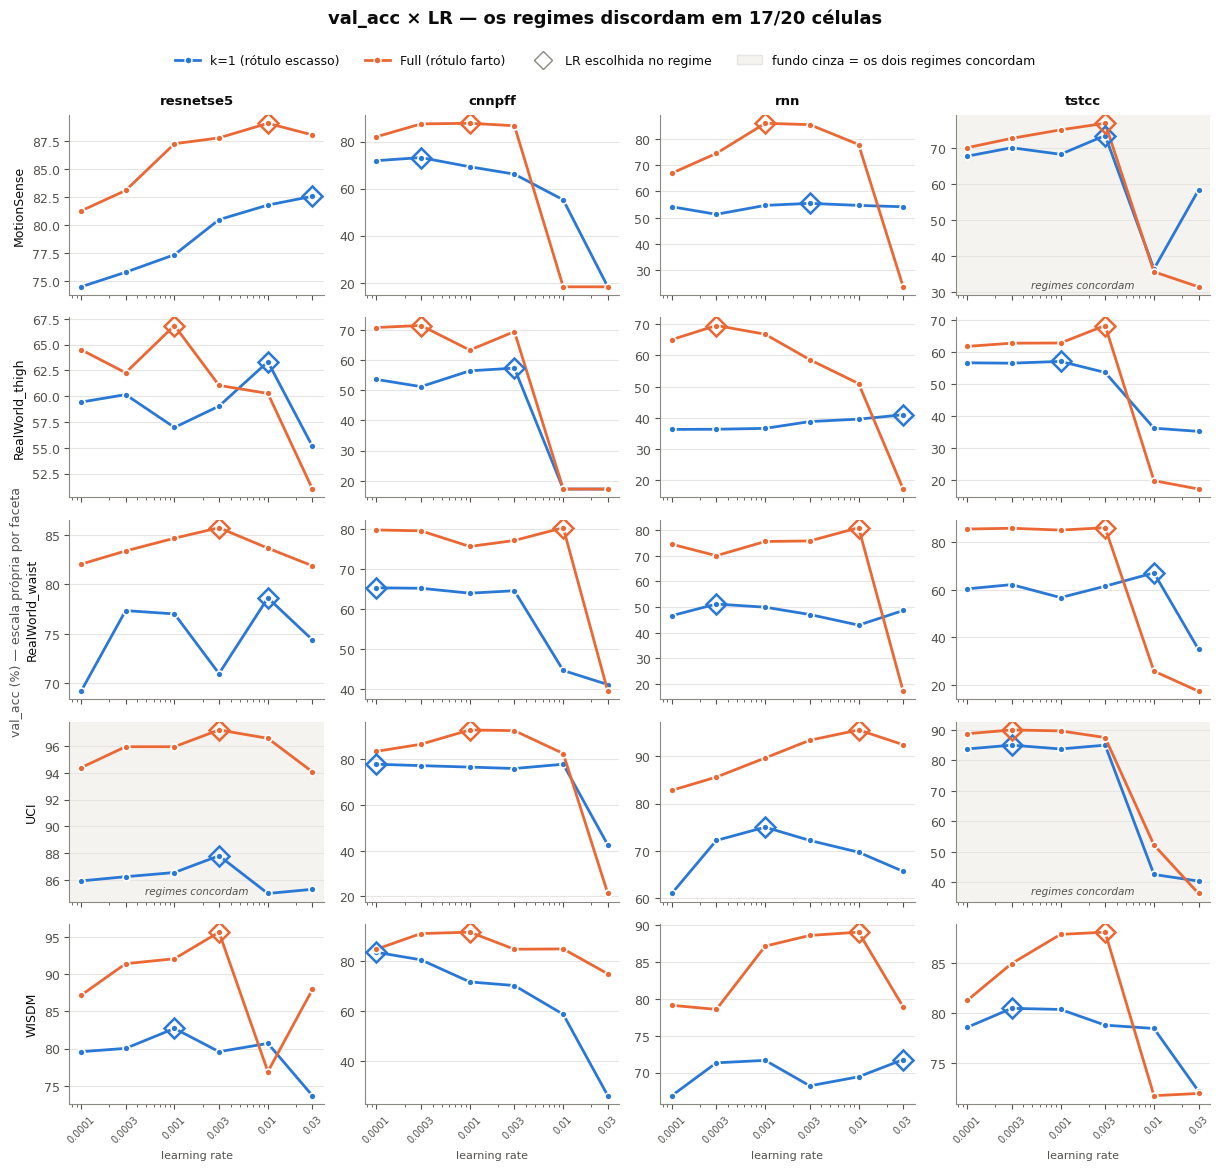

In [4]:
nrows, ncols = len(DATASETS_ORD), len(ENCODERS)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.1 * ncols, 2.25 * nrows),
                         sharex=True, squeeze=False)

escolhida = {(r.encoder, r.dataset, r.regime): r.lr for r in esc.itertuples()}
n_discorda = 0

for i, ds in enumerate(DATASETS_ORD):
    for j, enc in enumerate(ENCODERS):
        ax = axes[i][j]
        ax.set_axisbelow(True)
        ax.grid(True, axis="y", linewidth=0.8)
        for lado in ("top", "right"):
            ax.spines[lado].set_visible(False)

        picos = {}
        for reg in REGIMES:
            sub = (runs[(runs.encoder == enc) & (runs.target == ds) & (runs.n_shots == reg)]
                   .sort_values("lr"))
            if sub.empty:
                continue
            ax.plot(sub.lr, sub.val_acc * 100, color=COR_REGIME[reg],
                    linewidth=2, marker="o", markersize=5,
                    markeredgecolor="white", markeredgewidth=1.2, zorder=3)
            lr_e = escolhida.get((enc, ds, reg))
            if lr_e is not None and (sub.lr == lr_e).any():
                y = sub.loc[sub.lr == lr_e, "val_acc"].iloc[0] * 100
                ax.plot([lr_e], [y], marker="D", markersize=10, markerfacecolor="none",
                        markeredgecolor=COR_REGIME[reg], markeredgewidth=1.8, zorder=4)
                picos[reg] = lr_e

        if len(picos) == len(REGIMES):
            if len(set(picos.values())) > 1:
                n_discorda += 1
            else:
                # Destaca a EXCEÇÃO (regimes concordam), não a regra. Em tinta
                # neutra: cor de série é para dado, nunca para moldura.
                ax.set_facecolor("#f4f3ef")
                ax.text(0.5, 0.04, "regimes concordam", transform=ax.transAxes,
                        ha="center", fontsize=7.5, color=TINTA_2, style="italic")

        ax.set_xscale("log")
        ax.xaxis.set_major_locator(FixedLocator(LR_GRID))
        ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
        ax.tick_params(axis="x", labelrotation=45, labelsize=7)
        if i == 0:
            ax.set_title(enc, color=TINTA_1, fontweight="bold", pad=8)
        if j == 0:
            ax.set_ylabel(ds, color=TINTA_1, fontsize=9)
        if i == nrows - 1:
            ax.set_xlabel("learning rate", fontsize=8)

# Legenda: sempre presente com 2 séries; identidade nunca só pela cor.
maos = [plt.Line2D([], [], color=COR_REGIME[r], linewidth=2, marker="o",
                   markersize=5, markeredgecolor="white", label=ROTULO_REGIME[r])
        for r in REGIMES]
maos.append(plt.Line2D([], [], color=TINTA_3, marker="D", markersize=9, linestyle="none",
                       markerfacecolor="none", label="LR escolhida no regime"))
maos.append(plt.Rectangle((0, 0), 1, 1, facecolor="#f4f3ef", edgecolor=GRADE,
                          label="fundo cinza = os dois regimes concordam"))
fig.legend(handles=maos, loc="upper center", bbox_to_anchor=(0.5, 1.005), ncol=4)
fig.supylabel("val_acc (%) — escala própria por faceta", fontsize=9, color=TINTA_2)
fig.suptitle(f"val_acc × LR — os regimes discordam em {n_discorda}/{total} células",
             y=1.035, fontsize=13, fontweight="bold", color=TINTA_1)
fig.tight_layout()
plt.show()

## 3. As LRs escolhidas

LR é uma **magnitude ordenada**, então o mapa usa uma rampa **sequencial de um só
tom** (claro → escuro = LR maior). O valor vai escrito em cada célula: cor sozinha
nunca carrega o número.

Célula na borda da rampa (o tom mais escuro) = a busca escolheu o **teto da grade**,
e o ótimo pode estar fora dela.

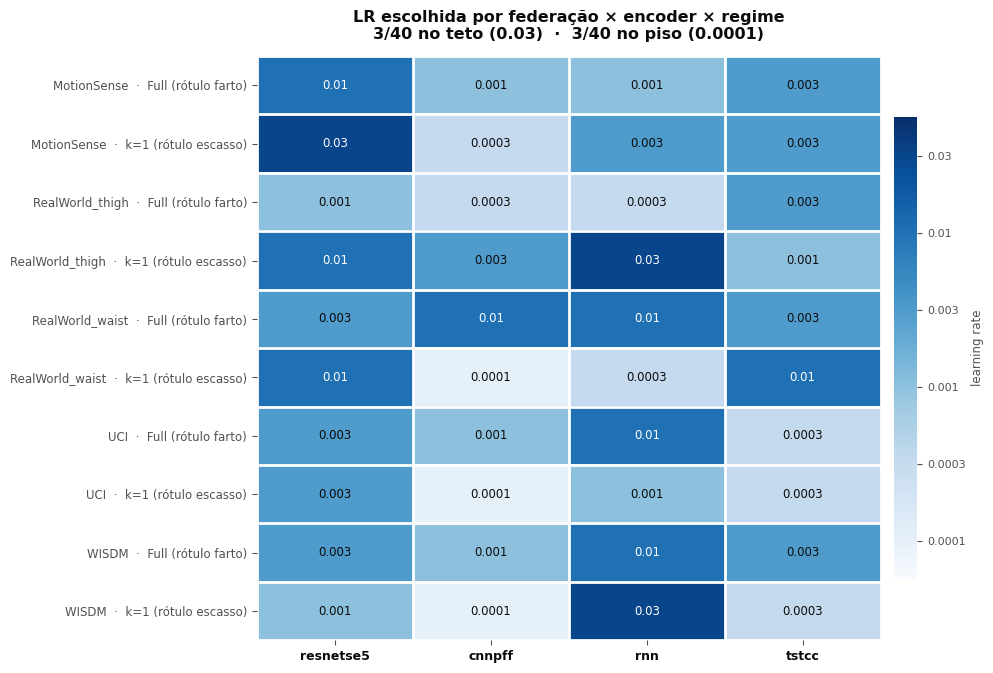

In [5]:
piv = (esc.assign(regime=lambda d: d.regime.map(ROTULO_REGIME))
          .pivot(index=["dataset", "regime"], columns="encoder", values="lr")
          .reindex(columns=list(ENCODERS)))

niveis = {lr: i for i, lr in enumerate(LR_GRID)}
Z = np.array([[niveis.get(v, np.nan) if pd.notna(v) else np.nan for v in linha]
              for linha in piv.to_numpy()], dtype=float)

fig, ax = plt.subplots(figsize=(1.45 * len(ENCODERS) + 4.2, 0.46 * len(piv) + 2.2))
im = ax.imshow(Z, cmap=RAMPA, vmin=-0.5, vmax=len(LR_GRID) - 0.5, aspect="auto")

ax.set_xticks(range(len(piv.columns)), piv.columns, fontweight="bold", color=TINTA_1)
ax.set_yticks(range(len(piv)), [f"{d}  ·  {r}" for d, r in piv.index], fontsize=8.5)
ax.set_xticks(np.arange(-.5, len(piv.columns), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(piv), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2)   # 2px de respiro entre células
ax.tick_params(which="minor", length=0)
for lado in ax.spines.values():
    lado.set_visible(False)

for a in range(Z.shape[0]):
    for b in range(Z.shape[1]):
        if np.isnan(Z[a, b]):
            ax.text(b, a, "—", ha="center", va="center", color=TINTA_3)
            continue
        v = piv.iloc[a, b]
        # tinta clara só onde o fundo é escuro o bastante para sustentá-la
        tinta = "white" if Z[a, b] >= len(LR_GRID) - 2 else TINTA_1
        ax.text(b, a, f"{v:g}", ha="center", va="center", fontsize=8.5, color=tinta)

cb = fig.colorbar(im, ax=ax, ticks=range(len(LR_GRID)), pad=0.02, fraction=0.035)
cb.ax.set_yticklabels([f"{lr:g}" for lr in LR_GRID], fontsize=8)
cb.outline.set_visible(False)
cb.set_label("learning rate", color=TINTA_2, fontsize=8.5)

n_teto = int((esc.lr == max(LR_GRID)).sum())
n_piso = int((esc.lr == min(LR_GRID)).sum())
ax.set_title(f"LR escolhida por federação × encoder × regime\n"
             f"{n_teto}/{len(esc)} no teto ({max(LR_GRID):g})  ·  "
             f"{n_piso}/{len(esc)} no piso ({min(LR_GRID):g})",
             fontsize=11.5, fontweight="bold", color=TINTA_1, pad=12)
fig.tight_layout()
plt.show()

## 4. Regret das regras de decisão

**Regret** = quantos pontos percentuais de `val_acc` a regra perde, naquele regime,
contra a melhor LR *daquele* regime. Zero = a regra acertou o ótimo.

| regra | como decide |
|---|---|
| **A — posto médio** | desenho D6 original: ranqueia as LRs dentro de cada regime e escolhe a de menor posto médio — **uma** LR por célula |
| **B — vencedora do `Full`** | usa em todos os regimes a melhor LR do `Full` |
| **C — por regime** | **implementada (D9)**: cada regime usa a sua |

C é zero por construção nos dois regimes medidos. O que a figura mostra é **o preço
que A e B pagam** — e onde: a barra do `k=1` é o few-shot, que é o coração das RQs.

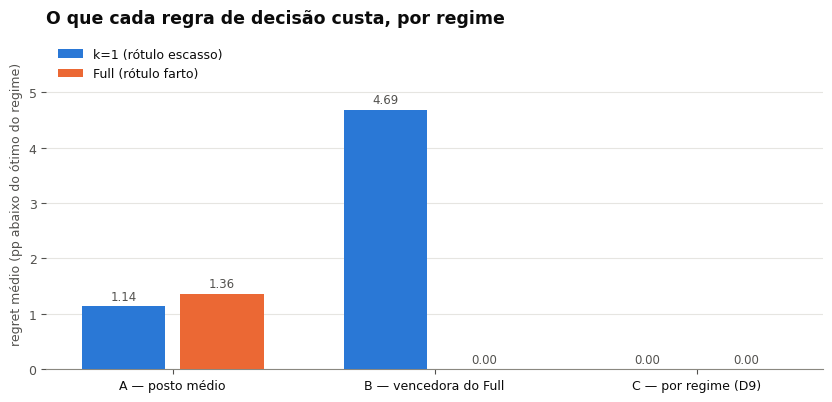

,regra,regime,regret médio (pp),pior célula (pp)
0,A — posto médio,1,1.14,4.97
1,A — posto médio,full,1.36,5.47
2,B — vencedora do Full,1,4.69,20.65
3,B — vencedora do Full,full,0.00,0.00
4,C — por regime (D9),1,0.00,0.00
5,C — por regime (D9),full,0.00,0.00


In [6]:
def regret_por_regra():
    linhas = []
    for enc in ENCODERS:
        for ds in DATASETS_ORD:
            cel = runs[(runs.encoder == enc) & (runs.target == ds)]
            s = {r: cel[cel.n_shots == r].set_index("lr").val_acc for r in REGIMES}
            if any(len(s[r]) < len(LR_GRID) for r in REGIMES):
                continue

            postos = {lr: 0.0 for lr in LR_GRID}
            for r in REGIMES:
                for pos, lr in enumerate(sorted(LR_GRID, key=lambda x: -s[r][x]), start=1):
                    postos[lr] += pos / len(REGIMES)
            media = {lr: np.mean([s[r][lr] for r in REGIMES]) for lr in LR_GRID}
            regra = {
                "A — posto médio": {r: min(LR_GRID, key=lambda lr: (postos[lr], -media[lr])) for r in REGIMES},
                "B — vencedora do Full": {r: s[REGIMES[1]].idxmax() for r in REGIMES},
                "C — por regime (D9)": {r: s[r].idxmax() for r in REGIMES},
            }
            for nome, escolha in regra.items():
                for r in REGIMES:
                    linhas.append(dict(regra=nome, regime=r, celula=f"{enc}/{ds}",
                                       regret=(s[r].max() - s[r][escolha[r]]) * 100))
    return pd.DataFrame(linhas)

reg = regret_por_regra()
resumo = reg.groupby(["regra", "regime"]).regret.agg(["mean", "max"]).reset_index()

fig, ax = plt.subplots(figsize=(8.4, 4.1))
ax.set_axisbelow(True)
ax.grid(True, axis="y", linewidth=0.8)
for lado in ("top", "right", "left"):
    ax.spines[lado].set_visible(False)

regras = list(dict.fromkeys(resumo.regra))
x = np.arange(len(regras)); w = 0.32
for m, r in enumerate(REGIMES):
    v = [resumo[(resumo.regra == g) & (resumo.regime == r)]["mean"].iloc[0] for g in regras]
    # 2px de respiro entre barras adjacentes; ponta arredondada na extremidade do dado
    barras = ax.bar(x + (m - 0.5) * (w + 0.055), v, w, label=ROTULO_REGIME[r],
                    color=COR_REGIME[r], linewidth=0, zorder=3)
    # rótulo direto: o valor não vive só na altura da barra
    for b, val in zip(barras, v):
        ax.text(b.get_x() + b.get_width() / 2, val + 0.06, f"{val:.2f}",
                ha="center", va="bottom", fontsize=8.5, color=TINTA_2)

ax.set_xticks(x, regras, color=TINTA_1)
ax.set_ylabel("regret médio (pp abaixo do ótimo do regime)")
ax.set_ylim(0, max(resumo["mean"]) * 1.28)
ax.legend(loc="upper left")
ax.set_title("O que cada regra de decisão custa, por regime",
             fontsize=12.5, fontweight="bold", color=TINTA_1, loc="left", pad=10)
fig.tight_layout()
plt.show()

resumo.rename(columns={"mean": "regret médio (pp)", "max": "pior célula (pp)"}).round(2)

## 5. O que a extensão da grade rendeu

A grade original tinha 4 pontos (`1e-4 … 3e-3`) e foi estendida para 6
(`… 1e-2, 3e-2`) em 2026-08-24, porque as escolhas estavam batendo no teto. Aqui
o ganho medido: por quanto a melhor LR da grade nova supera a melhor da antiga.

escolhas que migraram para as LRs novas: 11/40
ganho médio +0.59 pp | mediana +0.00 | máx +5.13 pp


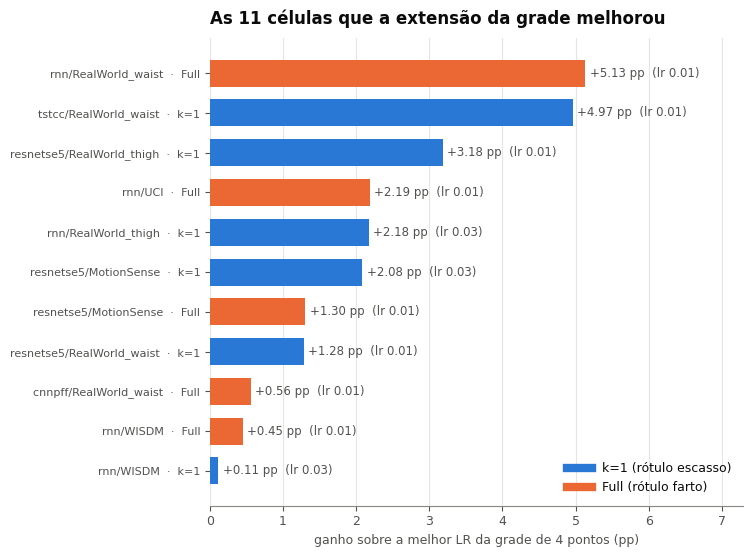

In [7]:
G_ANTIGA = [1e-4, 3e-4, 1e-3, 3e-3]
NOVAS = [lr for lr in LR_GRID if lr not in G_ANTIGA]

if not NOVAS:
    print("A grade não foi estendida — nada a comparar.")
else:
    linhas = []
    for r in esc.itertuples():
        c = runs[(runs.encoder == r.encoder) & (runs.target == r.dataset)
                 & (runs.n_shots == r.regime)].set_index("lr").val_acc
        if len(c) < len(LR_GRID):
            continue
        linhas.append(dict(celula=f"{r.encoder}/{r.dataset}", regime=r.regime,
                           ganho_pp=(c.max() - c.reindex(G_ANTIGA).max()) * 100,
                           lr_nova=r.lr, migrou=r.lr in NOVAS))
    g = pd.DataFrame(linhas)
    print(f"escolhas que migraram para as LRs novas: {int(g.migrou.sum())}/{len(g)}")
    print(f"ganho médio {g.ganho_pp.mean():+.2f} pp | mediana {g.ganho_pp.median():+.2f} "
          f"| máx {g.ganho_pp.max():+.2f} pp")

    top = g[g.ganho_pp > 0.01].sort_values("ganho_pp")
    if len(top):
        fig, ax = plt.subplots(figsize=(7.6, 0.34 * len(top) + 1.9))
        ax.set_axisbelow(True)
        ax.grid(True, axis="x", linewidth=0.8)
        for lado in ("top", "right", "left"):
            ax.spines[lado].set_visible(False)
        cores = [COR_REGIME[r] for r in top.regime]
        ax.barh([f"{c}  ·  {ROTULO_REGIME[r].split()[0]}" for c, r in zip(top.celula, top.regime)],
                top.ganho_pp, color=cores, linewidth=0, zorder=3, height=0.68)
        for y, (v, lr) in enumerate(zip(top.ganho_pp, top.lr_nova)):
            ax.text(v + 0.06, y, f"{v:+.2f} pp  (lr {lr:g})", va="center",
                    fontsize=8.5, color=TINTA_2)
        ax.set_xlim(0, top.ganho_pp.max() * 1.42)
        ax.set_xlabel("ganho sobre a melhor LR da grade de 4 pontos (pp)")
        ax.tick_params(axis="y", labelsize=8)
        maos = [plt.Line2D([], [], color=COR_REGIME[r], linewidth=6, label=ROTULO_REGIME[r])
                for r in REGIMES]
        ax.legend(handles=maos, loc="lower right")
        ax.set_title(f"As {len(top)} células que a extensão da grade melhorou",
                     fontsize=12, fontweight="bold", color=TINTA_1, loc="left", pad=10)
        fig.tight_layout()
        plt.show()

## 6. Tabela final — a LR que os drivers vão usar

`k=2` e `k=4` não aparecem porque não são buscados: eles **herdam a linha do `k=1`**
(D9). É a mesma tabela que `rqs.lr_escolhida.lr_de(encoder, dataset, k)` serve para
`run_rq1_federado.py` e `run_rq2.py`.

In [8]:
final = (esc.assign(regime=lambda d: d.regime.map({"1": "k=1  (serve k=1,2,4)",
                                                   str(FULL_SHOTS): "Full"}))
            .pivot(index=["dataset", "regime"], columns="encoder", values="lr")
            .reindex(columns=list(ENCODERS)))
concorda = (esc.pivot(index=["encoder", "dataset"], columns="regime", values="lr")
               .pipe(lambda t: (t[REGIMES[0]] == t[REGIMES[1]]).sum()))
print(f"regimes concordam sobre a LR em {concorda}/{len(esc) // len(REGIMES)} células "
      f"— por isso a LR é por regime (D9).")
final

regimes concordam sobre a LR em 3/20 células — por isso a LR é por regime (D9).


encoder                               resnetse5  cnnpff     rnn   tstcc
dataset         regime                                                 
MotionSense     Full                      0.010  0.0010  0.0010  0.0030
                k=1  (serve k=1,2,4)      0.030  0.0003  0.0030  0.0030
RealWorld_thigh Full                      0.001  0.0003  0.0003  0.0030
                k=1  (serve k=1,2,4)      0.010  0.0030  0.0300  0.0010
RealWorld_waist Full                      0.003  0.0100  0.0100  0.0030
                k=1  (serve k=1,2,4)      0.010  0.0001  0.0003  0.0100
UCI             Full                      0.003  0.0010  0.0100  0.0003
                k=1  (serve k=1,2,4)      0.003  0.0001  0.0010  0.0003
WISDM           Full                      0.003  0.0010  0.0100  0.0030
                k=1  (serve k=1,2,4)      0.001  0.0001  0.0300  0.0003